In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Read yearly crime data and group into a table 

In [ ]:

file_name = '2012026154636_2025_hangashat_meyda_plili.xlsx'

columns_to_read = ['YeshuvKod', 'StatisticGroupKod', 'StatisticTypeKod']

df = pd.read_excel(file_name, usecols=columns_to_read)

df_counts = df.groupby(['YeshuvKod', 'StatisticGroupKod']).size().unstack(fill_value=0)

df_counts.head()

StatisticGroupKod,-1,100,200,300,400,500,600,700,800,900,1000,1100,1200,1300,10000
YeshuvKod,,,,,,,,,,,,,,,
26.0,0,11,89,3,27,5,8,87,8,3,0,3,0,0,0
28.0,2,1,96,1,44,9,16,116,23,3,0,0,0,0,4
29.0,0,0,6,0,5,0,2,4,1,0,0,0,0,0,0
31.0,5,9,548,5,261,35,75,361,51,18,1,4,0,0,7
41.0,0,1,26,0,14,4,4,19,2,1,0,0,0,0,0


# Read cities data and merge with crime data

In [65]:
df_cities = pd.read_excel('cities_israel.xls', usecols=['symbol', 'coordinates','population'])
df_cities = df_cities.rename(columns={'symbol': 'YeshuvKod'})
print(df_cities.head())


   YeshuvKod  population   coordinates
0        967         NaN  2.040057e+09
1        472      6795.0  2.105263e+09
2        473     13151.0  2.160676e+09
3        935         NaN  1.865057e+09
4        958         NaN  1.850058e+09


In [66]:
df_merged = pd.merge(df_counts, df_cities, on='YeshuvKod', how='left')

# Remove rows with Nan in population size and coordinates. Create columns x and y with coordinates

In [ ]:

df_merged['coordinates'] = pd.to_numeric(df_merged['coordinates'], errors='coerce')
df_merged = df_merged[df_merged['coordinates'].notna()]
df_merged['coord_str'] = df_merged['coordinates'].astype(float).astype(int).astype(str)
df_merged['x'] = df_merged['coord_str'].str[:5].astype(float)
df_merged['y'] = df_merged['coord_str'].str[5:10].astype(float)

In [ ]:
df_merged['population'] = pd.to_numeric(df_merged['population'], errors='coerce')
df_merged = df_merged[df_merged['population'].notna()]
len(df_merged)

213

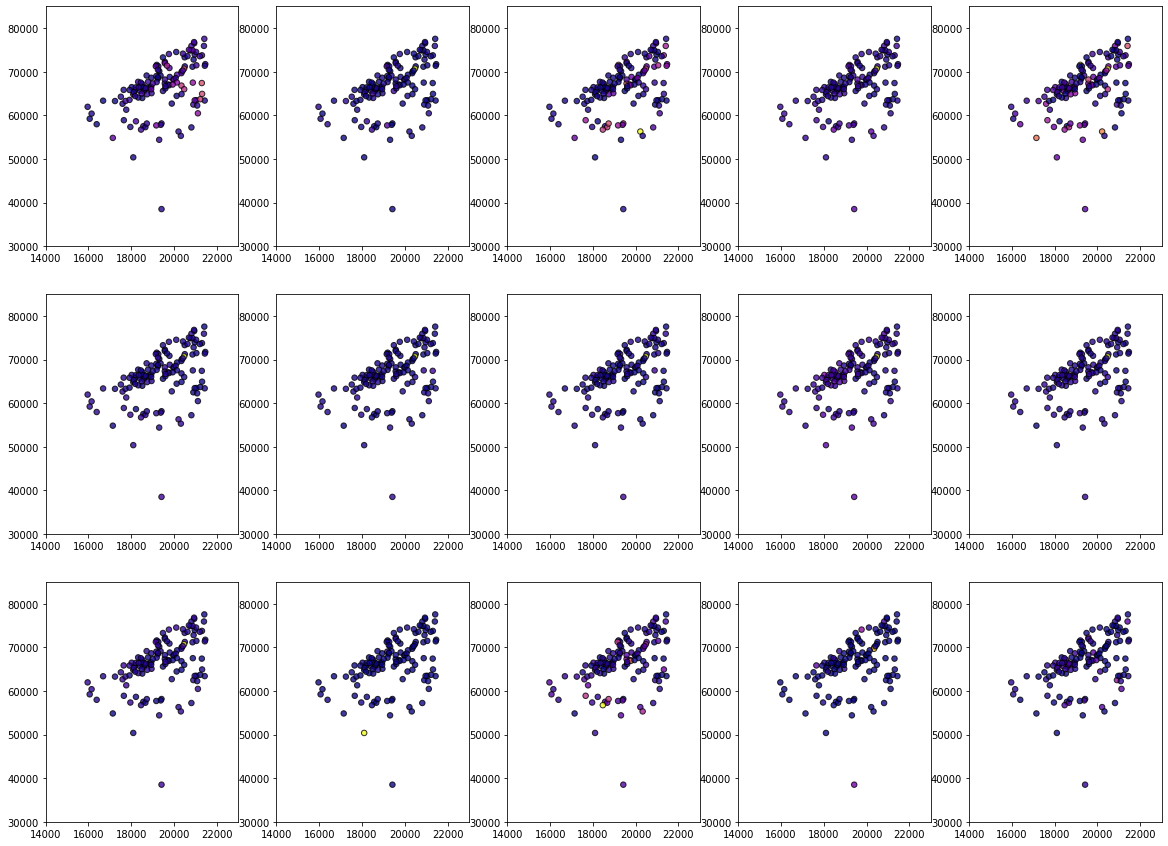

In [87]:
keys = df_merged.keys()
fig,axs = plt.subplots(3,5,figsize = (20,15))
for i,ax in enumerate(axs.flatten()):
    if (i<15):                      
        ax.scatter(df_merged['x'],df_merged['y'],c = np.log(df_merged[keys[i]]/df_merged['population'] + 1),cmap='plasma',s = 30,edgecolors = 'black',alpha = 0.8)
        ax.set_xlim([14000,23000])
        ax.set_ylim([3*10**4,8.5*10**4])
